# Pixel-cluster BDT baseline

This notebook is the feature-based baseline for the muon-collider BIB tutorial

1. load the signal/BIB cluster samples,
2. inspect cluster features and raw-hit multiplicities with plots,
3. train or load a sklearn Gradient Boosted Decision Tree,
4. evaluate score distributions, ROC curve, confusion matrix, and feature importance.

The Transformer tutorial notebook uses the saved BDT as a reference point.

In [2]:
import sys, os, json, math, time, random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

from mucoll_helpers.dataloader import load_pixel_data
from mucoll_helpers.tutorial_utils import (
    build_feature_matrix, classifier_summary_row,
    plot_feature_distributions, plot_hit_multiplicity,
    plot_feature_importance, plot_confusion_matrix,
    plot_roc_comparison, plot_leaderboard,
    plot_score_distributions, evaluate_classifier, benchmark_bdt,
)

DATA_DIR = Path('/pscratch/sd/s/sferrar2/mucoll')

## Configuration

In [3]:
SIGNAL_H5 = str(DATA_DIR / 'signal.h5')
BIB_H5    = str(DATA_DIR / 'BIB.h5')

MAX_RAW_HITS = 50
TEST_FRACTION = 0.2
VAL_FRACTION  = 0.1
RANDOM_SEED   = 42
BATCH_SIZE    = 256

OUTPUT_DIR = DATA_DIR / 'bdt_baseline_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BDT_MODEL_PATH = OUTPUT_DIR / 'bdt_gradient_boosting.joblib' # To Train BDT
# BDT_MODEL_PATH = BDT_MODEL_PATH / OUTPUT_DIR / 'bdt_gradient_boosting_trained.joblib' # To Load Trained BDT

for required_path in [SIGNAL_H5, BIB_H5]:
    if not Path(required_path).exists():
        raise FileNotFoundError(required_path)


## Load the same train/validation/test split

We use `load_pixel_data(...)` mostly to get the same labels and split indices used by the Transformer notebooks. The BDT itself will use the fixed-size cluster features from the HDF5 files.

In [4]:
data = load_pixel_data(
    SIGNAL_H5, BIB_H5,
    max_hits=MAX_RAW_HITS,
    batch=BATCH_SIZE,
    test_frac=TEST_FRACTION,
    val_frac=VAL_FRACTION,
    seed=RANDOM_SEED,
)

idx_train = np.asarray(data['idx_train'])
idx_val   = np.asarray(data['idx_val'])
idx_test  = np.asarray(data['idx_test'])
labels    = np.asarray(data['labels']).astype(int)
CLUSTER_FEATURES = list(data['feature_keys'])

print(f"Total clusters: {len(labels):,}")
print(f"Signal: {labels.sum():,}, BIB: {(labels == 0).sum():,}")
print(f"Train: {len(idx_train):,}, Val: {len(idx_val):,}, Test: {len(idx_test):,}")


  Pre-loading 512222 samples from signal.h5...
  Raw features: ('energy', 'time', 'x', 'y')
  Done. Tensor shape: torch.Size([512222, 50, 4])
  Pre-loading 692442 samples from BIB.h5...
  Raw features: ('energy', 'time', 'x', 'y')
  Done. Tensor shape: torch.Size([692442, 50, 4])
  Loaded 1204664 clusters (512222 signal + 692442 BIB)
Total clusters: 1,204,664
Signal: 512,222, BIB: 692,442
Train: 843,264, Val: 120,467, Test: 240,933


## Build the fixed-size BDT feature matrix


In [5]:
print('BDT features:')
for feature in CLUSTER_FEATURES:
    print('  ', feature)

X_bdt = build_feature_matrix(data, CLUSTER_FEATURES)
y_bdt = labels.astype(int)

X_train, y_train = X_bdt[idx_train], y_bdt[idx_train]
X_val,   y_val   = X_bdt[idx_val],   y_bdt[idx_val]
X_test,  y_test  = X_bdt[idx_test],  y_bdt[idx_test]

print('X_bdt:', X_bdt.shape)
print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")


BDT features:
   cluster_energy
   cluster_time
   cluster_r
   incident_angle
   cluster_size_tot
   cluster_size_x
   cluster_size_y
   cluster_rms_x
   cluster_rms_y
   cluster_skew_x
   cluster_skew_y
   cluster_aspect
   cluster_ecc
X_bdt: (1204664, 13)
Train: 843,264  Val: 120,467  Test: 240,933


## Quick feature plots


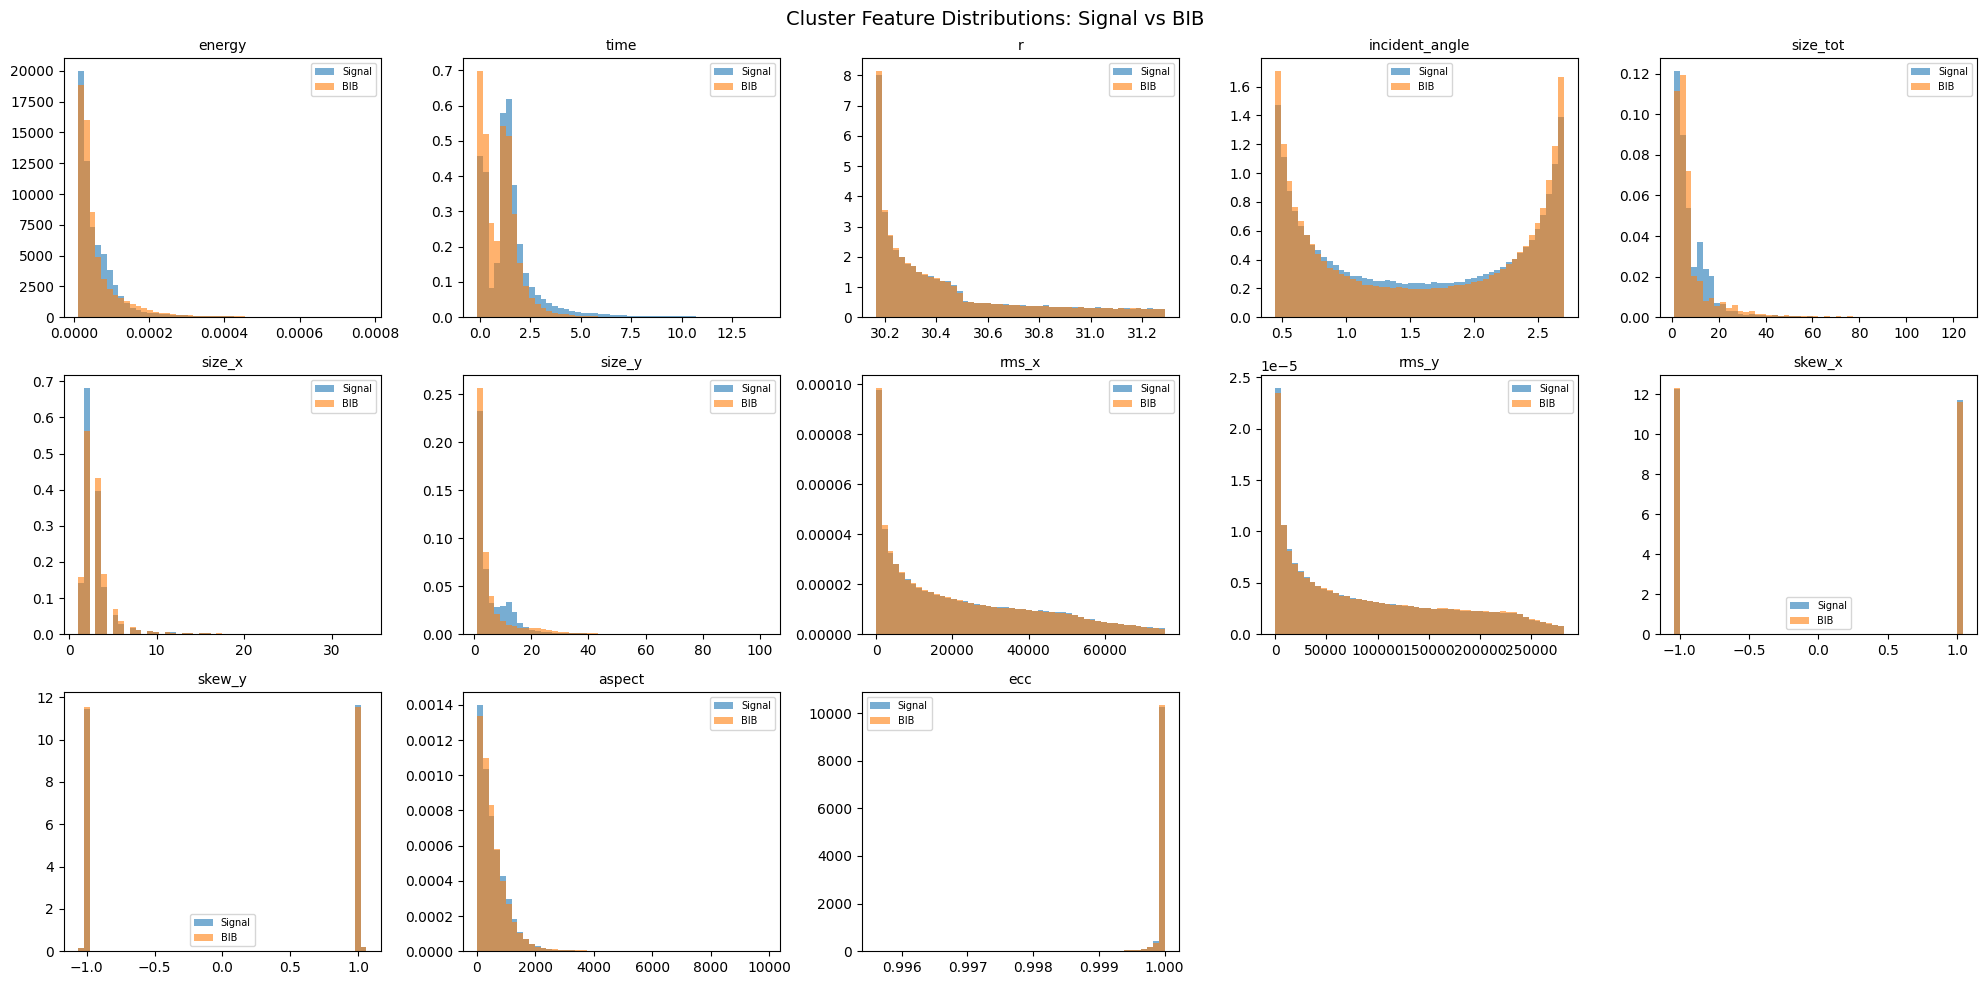

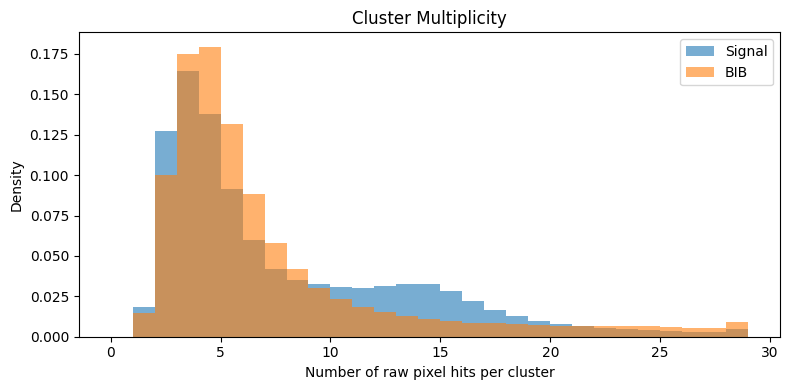

Raw hits per cluster — median: 5, mean: 12.2, max: 3381


In [6]:
plot_feature_distributions(data, labels)
plot_hit_multiplicity(data, labels)


## Train or load the BDT

In [7]:
TRAIN_BDT = not BDT_MODEL_PATH.exists()

if TRAIN_BDT:
    print('Training BDT...')
    t0 = time.time()
    bdt = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_SEED,
    )
    bdt.fit(X_train, y_train)
    joblib.dump(bdt, BDT_MODEL_PATH)
    print(f'Saved {BDT_MODEL_PATH}')
    print(f'Training time: {(time.time() - t0):.1f} s')
else:
    print(f'Loading {BDT_MODEL_PATH}')
    bdt = joblib.load(BDT_MODEL_PATH)


Training BDT...
Saved /pscratch/sd/s/sferrar2/mucoll/bdt_baseline_outputs/bdt_gradient_boosting.joblib
Training time: 800.4 s


## Evaluate the BDT

Validation AUC: 0.847586881670594
Test AUC:       0.8477662817673717

BDT AUC: 0.8478
Accuracy: 0.7667
  Signal eff = 0.500  ->  1 - BIB eff = 0.9236
  Signal eff = 0.800  ->  1 - BIB eff = 0.7113
  Signal eff = 0.900  ->  1 - BIB eff = 0.5610
  Signal eff = 0.950  ->  1 - BIB eff = 0.4510


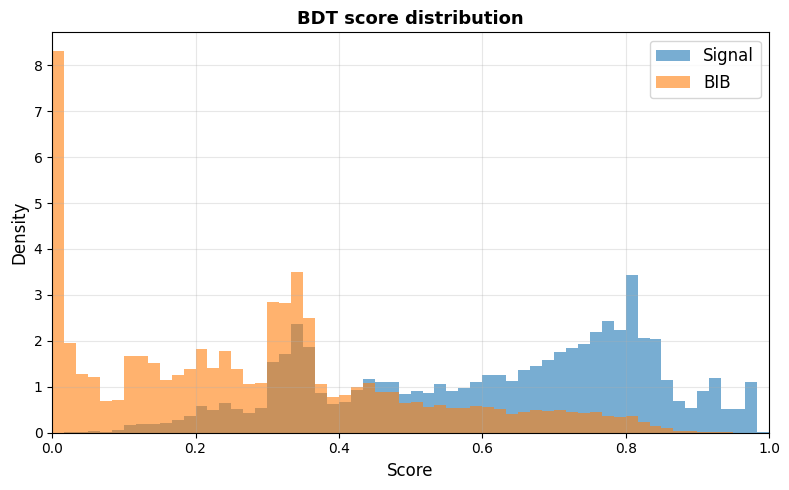

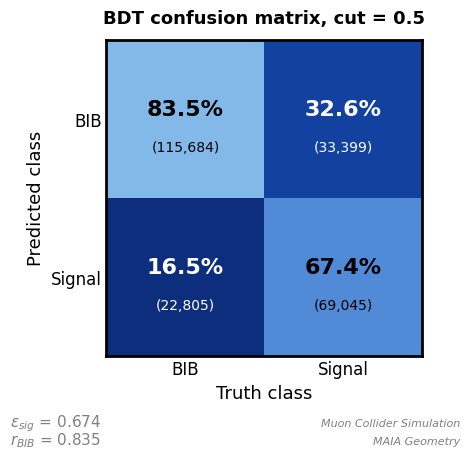

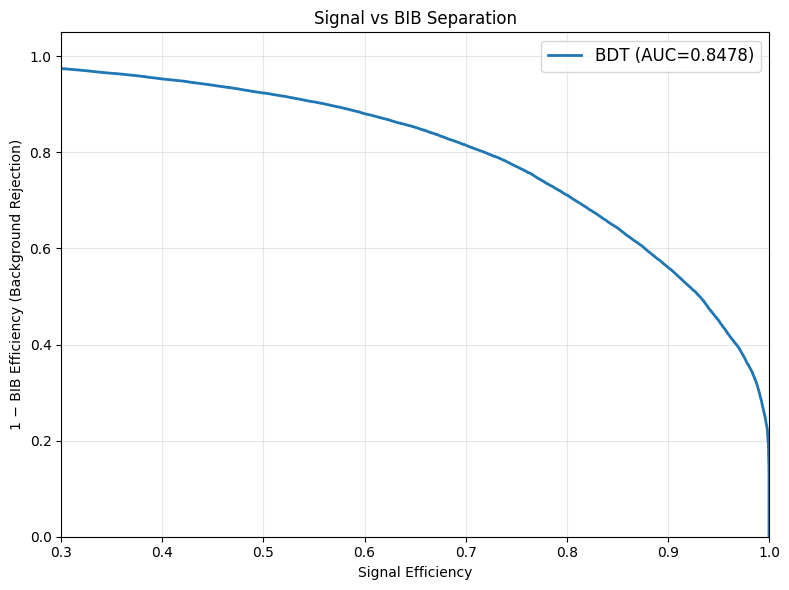

In [8]:
bdt_scores_val = bdt.predict_proba(X_val)[:, 1]
bdt_scores_test = bdt.predict_proba(X_test)[:, 1]

print('Validation AUC:', roc_auc_score(y_val, bdt_scores_val))
print('Test AUC:      ', roc_auc_score(y_test, bdt_scores_test))

bdt_results = evaluate_classifier(y_test, bdt_scores_test, 'BDT')
plot_score_distributions(y_test, bdt_scores_test, title='BDT score distribution')
plot_confusion_matrix(y_test, bdt_scores_test, cut=0.5, title='BDT confusion matrix, cut = 0.5')
plot_roc_comparison({'BDT': bdt_results})


## Feature importance

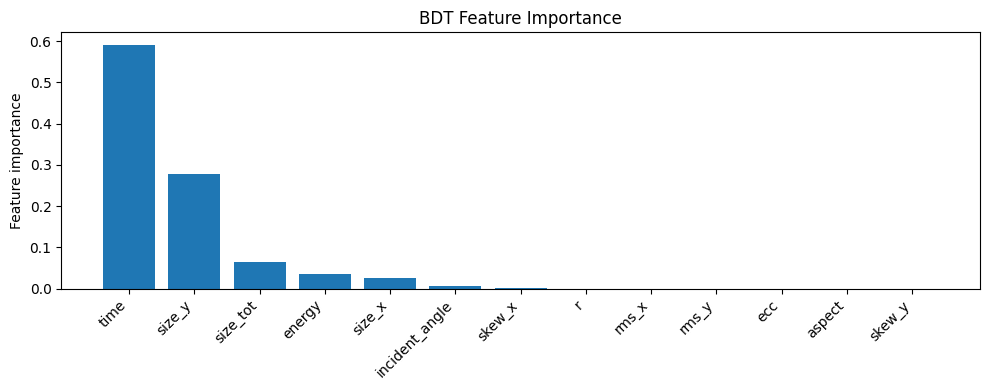

Saved feature importances to /global/cfs/cdirs/m5197/sferrar2/ML4FPS/REAL_Jupyter/2026-gatech/sessions/04_muon_col/tutorial/bdt_baseline_outputs/bdt_feature_importance.csv


,feature,importance
1,cluster_time,0.591741
6,cluster_size_y,0.277429
4,cluster_size_tot,0.064396
0,cluster_energy,0.034928
5,cluster_size_x,0.024903
3,incident_angle,0.005942
9,cluster_skew_x,0.000430
2,cluster_r,0.000125


In [9]:
plot_feature_importance(bdt, CLUSTER_FEATURES)

if hasattr(bdt, 'feature_importances_'):
    importances = pd.DataFrame({
        'feature': CLUSTER_FEATURES,
        'importance': bdt.feature_importances_,
    }).sort_values('importance', ascending=False)
    importances.to_csv(OUTPUT_DIR / 'bdt_feature_importance.csv', index=False)
    print('Saved feature importances to', OUTPUT_DIR / 'bdt_feature_importance.csv')
    display(importances.head(8))
else:
    print('This BDT object does not expose feature_importances_.')


## Save a small BDT summary for the Transformer leaderboard


 BDT Benchmark
  Trees:                  200
  Max depth:                3
  Serialized size:    270,740 bytes  (264.4 KB)
  AUC:                 0.8477
  FoM:                 0.1560

Rank  Model                          AUC  Size (KB)      FoM
------------------------------------------------------------
1     BDT (baseline)              0.8477      264.4   0.1560


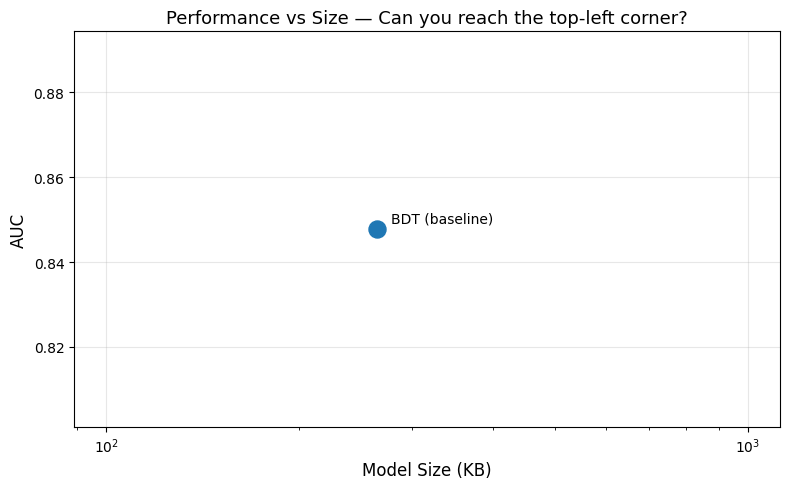

,name,kind,test_auc,test_bib_rej_at_sig_eff_0p80,test_bib_rej_at_sig_eff_0p90,test_bib_rej_at_sig_eff_0p95,model_path,model_size_bytes,fom
0,BDT,BDT,0.84774,0.710923,0.562702,0.451234,/global/cfs/cdirs/m5197/sferrar2/ML4FPS/REAL_J...,270740,0.156048


Saved BDT summary to /global/cfs/cdirs/m5197/sferrar2/ML4FPS/REAL_Jupyter/2026-gatech/sessions/04_muon_col/tutorial/bdt_baseline_outputs/bdt_leaderboard_row.csv


In [10]:
bdt_bench = benchmark_bdt(bdt, bdt_results['auc'])
plot_leaderboard([
    ('BDT (baseline)', bdt_bench['auc'], bdt_bench['size_bytes'], bdt_bench['fom']),
])

row = classifier_summary_row('BDT', 'BDT', y_test, bdt_scores_test, BDT_MODEL_PATH)
row.update({
    'model_size_bytes': bdt_bench['size_bytes'],
    'fom': bdt_bench['fom'],
})
summary = pd.DataFrame([row])
summary.to_csv(OUTPUT_DIR / 'bdt_leaderboard_row.csv', index=False)
display(summary)
print('Saved BDT summary to', OUTPUT_DIR / 'bdt_leaderboard_row.csv')
